In [8]:
from google.colab import files
uploaded = files.upload()

Saving project.xlsx to project.xlsx


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [11]:
df = pd.read_excel("project.xlsx")

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df = df.dropna(subset=['order_date'])

df = df.sort_values('order_date')

df.head()

,order_date,total_orders,total_cancellations,wastage_flag,fraud_flag
0,2024-01-01,120,10.0,0.0,0.0
1,2024-01-02,190,15.0,0.0,0.0
2,2024-01-03,141,8.0,0.0,0.0
3,2024-01-04,181,20.0,0.0,0.0
4,2024-01-05,145,18.0,0.0,0.0


In [12]:
data = df[['total_orders']]
data.head()

,total_orders
0,120
1,190
2,141
3,181
4,145


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.2 ],
       [0.9 ],
       [0.41],
       [0.81],
       [0.45]])

In [14]:
X = []
y = []

for i in range(10, len(scaled_data)):
    X.append(scaled_data[i-10:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(509, 10, 1) (509, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.fit(X, y, epochs=20, batch_size=8)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1554
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0865
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0855
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0875
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0841
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0862
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0845
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0848
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0844
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0842
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0844
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0844
Epoch 13/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0840
Epoch 14/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0860
Epoch 15/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0849
Epoch 16/20
64/64 ━

In [17]:
predictions = model.predict(X)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [18]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y.reshape(-1,1))

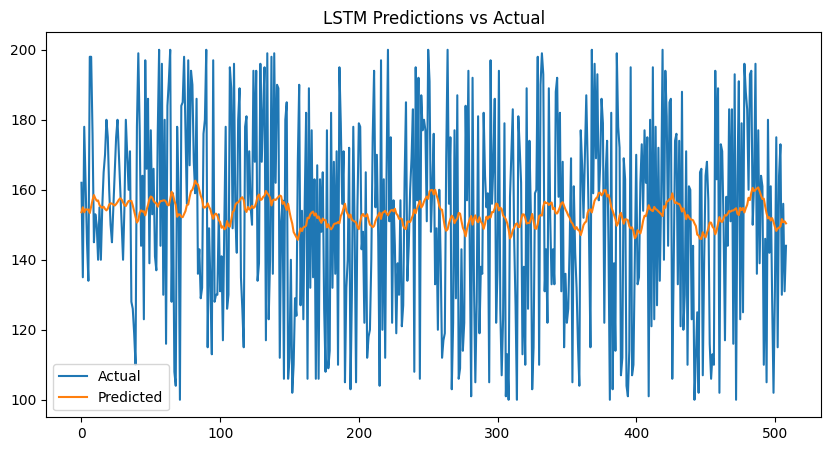

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("LSTM Predictions vs Actual")
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual, predictions))
print("RMSE:", rmse)

RMSE: 28.855551024577984


Food Delivery Fraud Detection & Forecasting
EDA + ARIMA + LSTM


In [21]:
import pandas as pd

df = pd.read_excel("project.xlsx")

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df = df.dropna(subset=['order_date'])
df = df.sort_values('order_date')

df.head()

,order_date,total_orders,total_cancellations,wastage_flag,fraud_flag
0,2024-01-01,120,10.0,0.0,0.0
1,2024-01-02,190,15.0,0.0,0.0
2,2024-01-03,141,8.0,0.0,0.0
3,2024-01-04,181,20.0,0.0,0.0
4,2024-01-05,145,18.0,0.0,0.0


In [22]:
df.describe()
df.isnull().sum()

,0
order_date,0
total_orders,0
total_cancellations,0
wastage_flag,0
fraud_flag,0


ARIMA MODEL

In [25]:
df['total_orders'] = pd.to_numeric(df['total_orders'], errors='coerce')

In [26]:
df = df.dropna(subset=['total_orders'])

In [29]:
df['total_orders'] = pd.to_numeric(df['total_orders'], errors='coerce')
df = df.dropna(subset=['total_orders'])

series = df['total_orders']

In [32]:
print(df.columns)

Index(['total_orders', 'total_cancellations', 'wastage_flag', 'fraud_flag'], dtype='object')


In [33]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)


Index(['total_orders', 'total_cancellations', 'wastage_flag', 'fraud_flag'], dtype='object')


In [35]:
df['total_orders'] = pd.to_numeric(df['total_orders'], errors='coerce')
df = df.dropna(subset=['total_orders'])

series = df['total_orders']

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


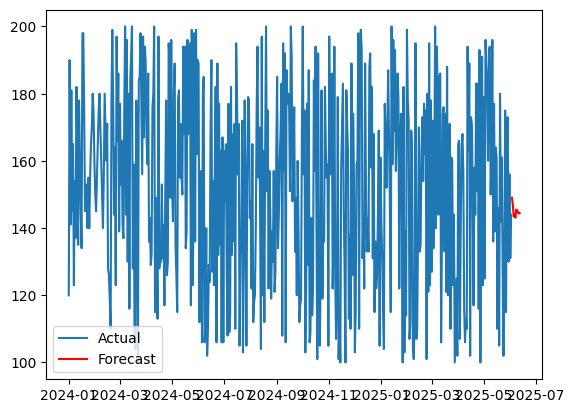

In [36]:
forecast = model_fit.forecast(steps=10)

import matplotlib.pyplot as plt

plt.plot(series, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()

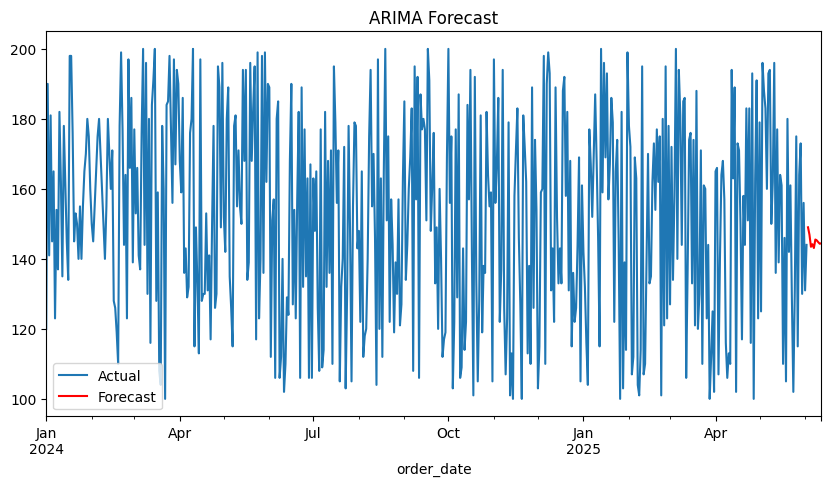

In [37]:
series.plot(figsize=(10,5), label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()